# **Module 2 — : HEALTH RISK PREDICTION**
### MedAI Nexus | XGBoost + CDC BRFSS Diabetes Health Indicators
---
- **Dataset :** https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset
- **Model   :** XGBoost Classifier + SHAP Explainability  
- **Task    :** Binary classification — Diabetic / Non-Diabetic
- **Goal:** Load → Explore (EDA) → Clean → Handle Imbalance (SMOTE) → Feature Selection → Split Data → Train Model (XGBoost) → Evaluate (Metrics + ROC) → Explain (SHAP) → Ready for Prediction




### **Objective**:
To develop a machine learning model that predicts the risk of diabetes using health indicators and lifestyle-related features from a large-scale healthcare dataset.

##1. Mount Drive
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##2. Install & Import Dependencies
---

In [ ]:
!pip uninstall -y xgboost
!pip install xgboost==1.7.6

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 5.7 MB/s eta 0:00:00


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
np.random.seed(42)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score, precision_recall_curve
import xgboost as xgb
import shap
shap.initjs()

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Install imbalanced-learn (not pre-installed on Colab)
!pip install imbalanced-learn -q

print("Libraries loaded successfully.")

Libraries loaded successfully.


##2. Load dataset
---

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets/risk/diabetes_012_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


##3. Dataset Overview & Feature Descriptions
---

In [ ]:
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['Diabetes_012'].value_counts())
print(f"\nClass balance: {df['Diabetes_012'].value_counts(normalize=True).round(3)}")

Shape: (253680, 22)

Target distribution:
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Class balance: Diabetes_012
0.0    0.842
2.0    0.139
1.0    0.018
Name: proportion, dtype: float64


In [ ]:
# Basic statistics
#------------------------

print("────────────────── Data Types & Missing Values ─────────────────────")
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notnull().sum(),
    'missing' : df.isnull().sum(),
    'unique'  : df.nunique(),
    'min'     : df.min(),
    'max'     : df.max()
})
print(info_df.to_string())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


────────────────── Data Types & Missing Values ─────────────────────
                        dtype  non_null  missing  unique   min   max
Diabetes_012          float64    253680        0       3   0.0   2.0
HighBP                float64    253680        0       2   0.0   1.0
HighChol              float64    253680        0       2   0.0   1.0
CholCheck             float64    253680        0       2   0.0   1.0
BMI                   float64    253680        0      84  12.0  98.0
Smoker                float64    253680        0       2   0.0   1.0
Stroke                float64    253680        0       2   0.0   1.0
HeartDiseaseorAttack  float64    253680        0       2   0.0   1.0
PhysActivity          float64    253680        0       2   0.0   1.0
Fruits                float64    253680        0       2   0.0   1.0
Veggies               float64    253680        0       2   0.0   1.0
HvyAlcoholConsump     float64    253680        0       2   0.0   1.0
AnyHealthcare         float64    2

In [ ]:
# Feature descriptions — memorise these for your presentation
#----------------------------------------------------------------

FEATURE_DESCRIPTIONS = {
    'Diabetes_012'       : 'TARGET — 0: No diabetes, 1: Prediabetes or diabetes',
    'HighBP'                : 'High blood pressure (0=No, 1=Yes)',
    'HighChol'              : 'High cholesterol (0=No, 1=Yes)',
    'CholCheck'             : 'Cholesterol check in last 5 years (0=No, 1=Yes)',
    'BMI'                   : 'Body Mass Index — only continuous feature',
    'Smoker'                : 'Smoked 100+ cigarettes in lifetime (0=No, 1=Yes)',
    'Stroke'                : 'Ever had a stroke (0=No, 1=Yes)',
    'HeartDiseaseorAttack'  : 'Coronary heart disease or heart attack (0=No, 1=Yes)',
    'PhysActivity'          : 'Physical activity in past 30 days (0=No, 1=Yes)',
    'Fruits'                : 'Consume fruits 1+ times per day (0=No, 1=Yes)',
    'Veggies'               : 'Consume vegetables 1+ times per day (0=No, 1=Yes)',
    'HvyAlcoholConsump'     : 'Heavy alcohol use (men >14/wk, women >7/wk)',
    'AnyHealthcare'         : 'Any kind of health coverage (0=No, 1=Yes)',
    'NoDocbcCost'           : 'Could not see doctor due to cost in past year',
    'GenHlth'               : 'General health scale: 1=Excellent, 5=Poor',
    'MentHlth'              : 'Days of poor mental health in past 30 days (0-30)',
    'PhysHlth'              : 'Days of poor physical health in past 30 days (0-30)',
    'DiffWalk'              : 'Difficulty walking or climbing stairs (0=No, 1=Yes)',
    'Sex'                   : 'Biological sex (0=Female, 1=Male)',
    'Age'                   : 'Age category: 1=18-24, 2=25-29, ..., 13=80+',
    'Education'             : 'Education level: 1=Never attended, 6=College grad',
    'Income'                : 'Income level: 1=<$10k, 8=>$75k',
}

# Categorical vs numerical features
BINARY_FEATURES = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex'
]
ORDINAL_FEATURES = ['GenHlth','MentHlth','PhysHlth','Age','Education','Income']
CONTINUOUS_FEATURES = ['BMI']
TARGET = 'Diabetes_012'
ALL_FEATURES = BINARY_FEATURES + ORDINAL_FEATURES + CONTINUOUS_FEATURES

print(f"Binary features   : {len(BINARY_FEATURES)}")
print(f"Ordinal features  : {len(ORDINAL_FEATURES)}")
print(f"Continuous features: {len(CONTINUOUS_FEATURES)}")
print(f"Total features    : {len(ALL_FEATURES)}")
print()

desc_df = pd.DataFrame.from_dict(
    FEATURE_DESCRIPTIONS, orient='index', columns=['Description']
)
print(desc_df.to_string())


Binary features   : 14
Ordinal features  : 6
Continuous features: 1
Total features    : 21

                                                               Description
Diabetes_012           TARGET — 0: No diabetes, 1: Prediabetes or diabetes
HighBP                                   High blood pressure (0=No, 1=Yes)
HighChol                                    High cholesterol (0=No, 1=Yes)
CholCheck                  Cholesterol check in last 5 years (0=No, 1=Yes)
BMI                              Body Mass Index — only continuous feature
Smoker                    Smoked 100+ cigarettes in lifetime (0=No, 1=Yes)
Stroke                                     Ever had a stroke (0=No, 1=Yes)
HeartDiseaseorAttack  Coronary heart disease or heart attack (0=No, 1=Yes)
PhysActivity               Physical activity in past 30 days (0=No, 1=Yes)
Fruits                       Consume fruits 1+ times per day (0=No, 1=Yes)
Veggies                  Consume vegetables 1+ times per day (0=No, 1=Yes)
HvyAlcoh

In [ ]:
# Missing Values
#------------------
print("Missing values:\n", df.isnull().sum())

Missing values:
 Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [ ]:
# Statistical Summary
#----------------------
df.describe().round(2)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.3,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.7,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.0,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.0,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.0,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.0,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,2.0,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


##4. EDA
---

###4.1 Target Distribution & Imbalance Analysis

── Target Distribution ─────────────────────────────
Class 0.0: 213,703 (84.24%)
Class 2.0: 35,346 (13.93%)
Class 1.0: 4,631 (1.83%)


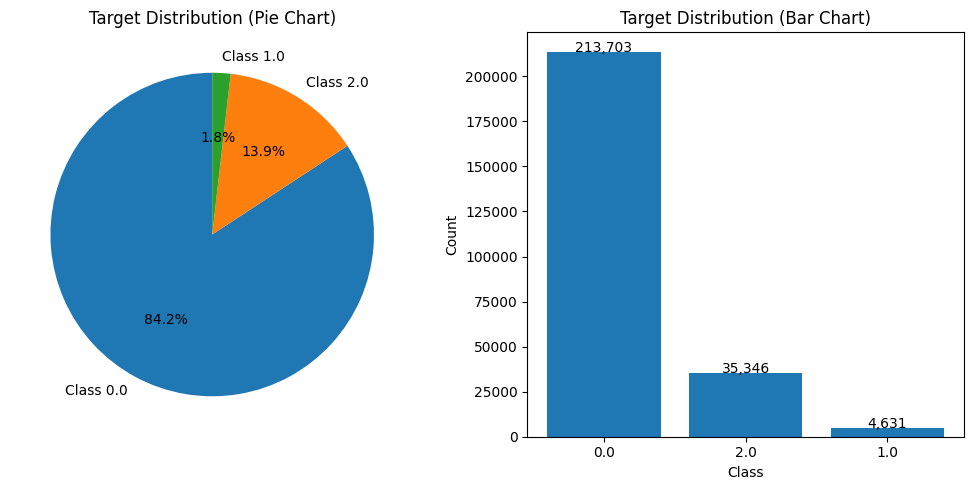

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def target_imbalance_analysis(df, target_col):

    # ─────────────────────────────────────────
    # STEP 1: Count values
    # ─────────────────────────────────────────
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100

    print("── Target Distribution ─────────────────────────────")
    for cls in counts.index:
        print(f"Class {cls}: {counts[cls]:,} ({percentages[cls]:.2f}%)")

    # ─────────────────────────────────────────
    # STEP 2: Imbalance Ratio
    # ─────────────────────────────────────────
    if len(counts) == 2:
        majority = counts.max()
        minority = counts.min()
        ratio = majority / minority

        print(f"\nImbalance Ratio (Majority:Minority) = {ratio:.2f} : 1")

        if ratio > 3:
            print("⚠️ Dataset is imbalanced → Use SMOTE / class weights")
        else:
            print("✔ Dataset is relatively balanced")

    # ─────────────────────────────────────────
    # STEP 3: Visualization
    # ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10,5))

    # Pie chart
    axes[0].pie(
        counts,
        labels=[f"Class {i}" for i in counts.index],
        autopct='%1.1f%%',
        startangle=90
    )
    axes[0].set_title("Target Distribution (Pie Chart)")

    # Bar chart
    axes[1].bar(
        [str(i) for i in counts.index],
        counts.values
    )
    axes[1].set_title("Target Distribution (Bar Chart)")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")

    # Add count labels
    for i, v in enumerate(counts.values):
        axes[1].text(i, v, f"{v:,}", ha='center')

    plt.tight_layout()
    plt.show()


# CALL FUNCTION
target_imbalance_analysis(df, "Diabetes_012")

###4.2 Feature Distribution

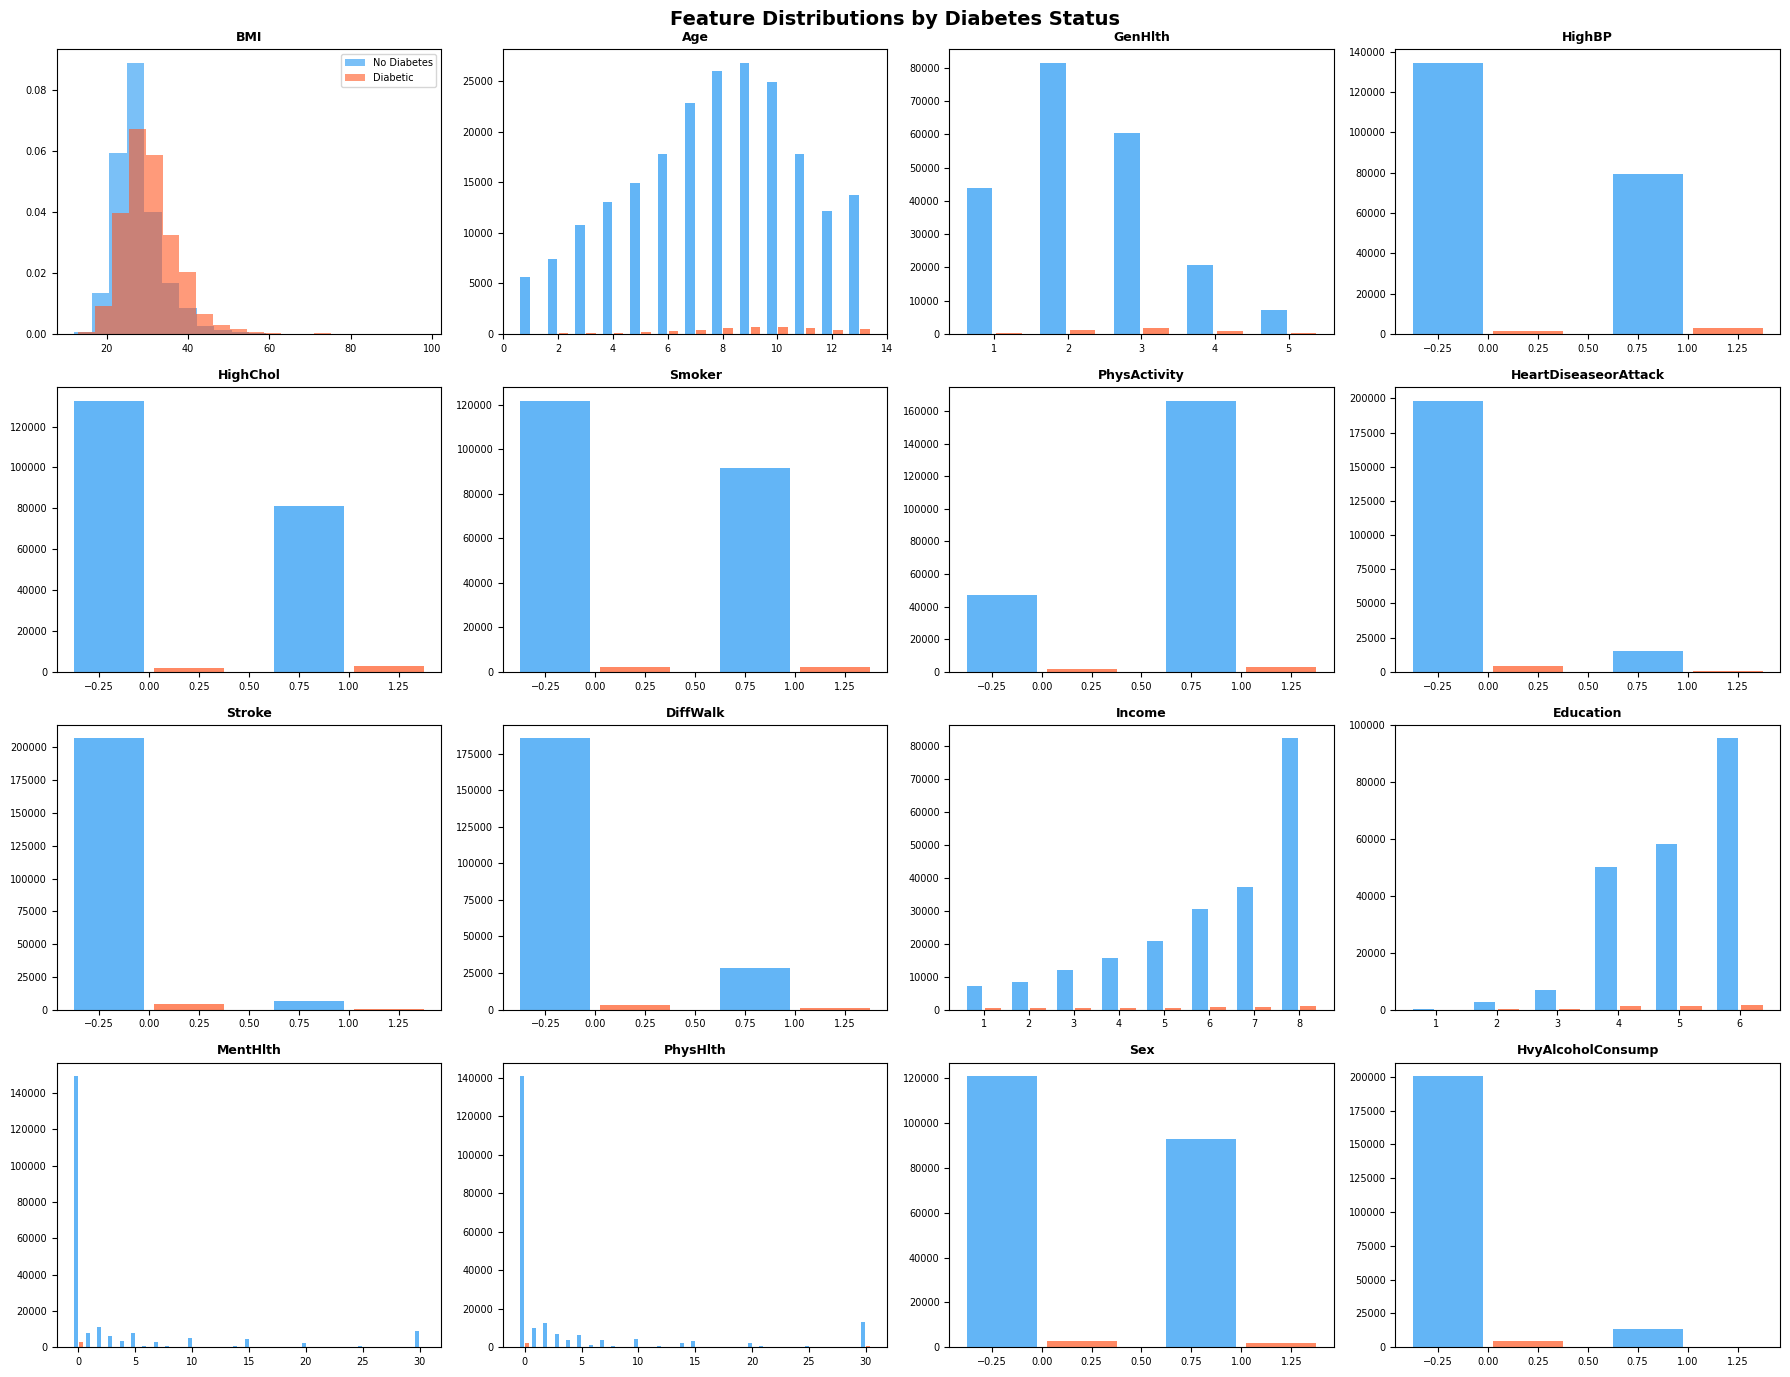

Saved: feature_distributions.png


In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

key_features = [
    'BMI','Age','GenHlth','HighBP','HighChol',
    'Smoker','PhysActivity','HeartDiseaseorAttack',
    'Stroke','DiffWalk','Income','Education',
    'MentHlth','PhysHlth','Sex','HvyAlcoholConsump'
]

for i, feat in enumerate(key_features):
    ax = axes[i]

    for label, color in [(0, '#2196F3'), (1, '#FF5722')]:
        subset = df[df[TARGET] == label][feat]

        # FIX: handle ALL categorical (binary + ordinal)
        if feat in BINARY_FEATURES + ORDINAL_FEATURES:
            counts = subset.value_counts().sort_index()

            positions = [
                x + (0.2 if label == 1 else -0.2)
                for x in counts.index
            ]

            ax.bar(
                positions,
                counts.values,
                width=0.35,
                color=color,
                alpha=0.7,
                label='No Diabetes' if label == 0 else 'Diabetic'
            )

        else:
            ax.hist(
                subset,
                bins=20,
                color=color,
                alpha=0.6,
                density=True,
                label='No Diabetes' if label == 0 else 'Diabetic'
            )

    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

    # Show legend only once
    if i == 0:
        ax.legend(fontsize=7)

# Hide extra plots if any
for j in range(len(key_features), len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Feature Distributions by Diabetes Status',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: feature_distributions.png")

###4.3 Correlation heatmap

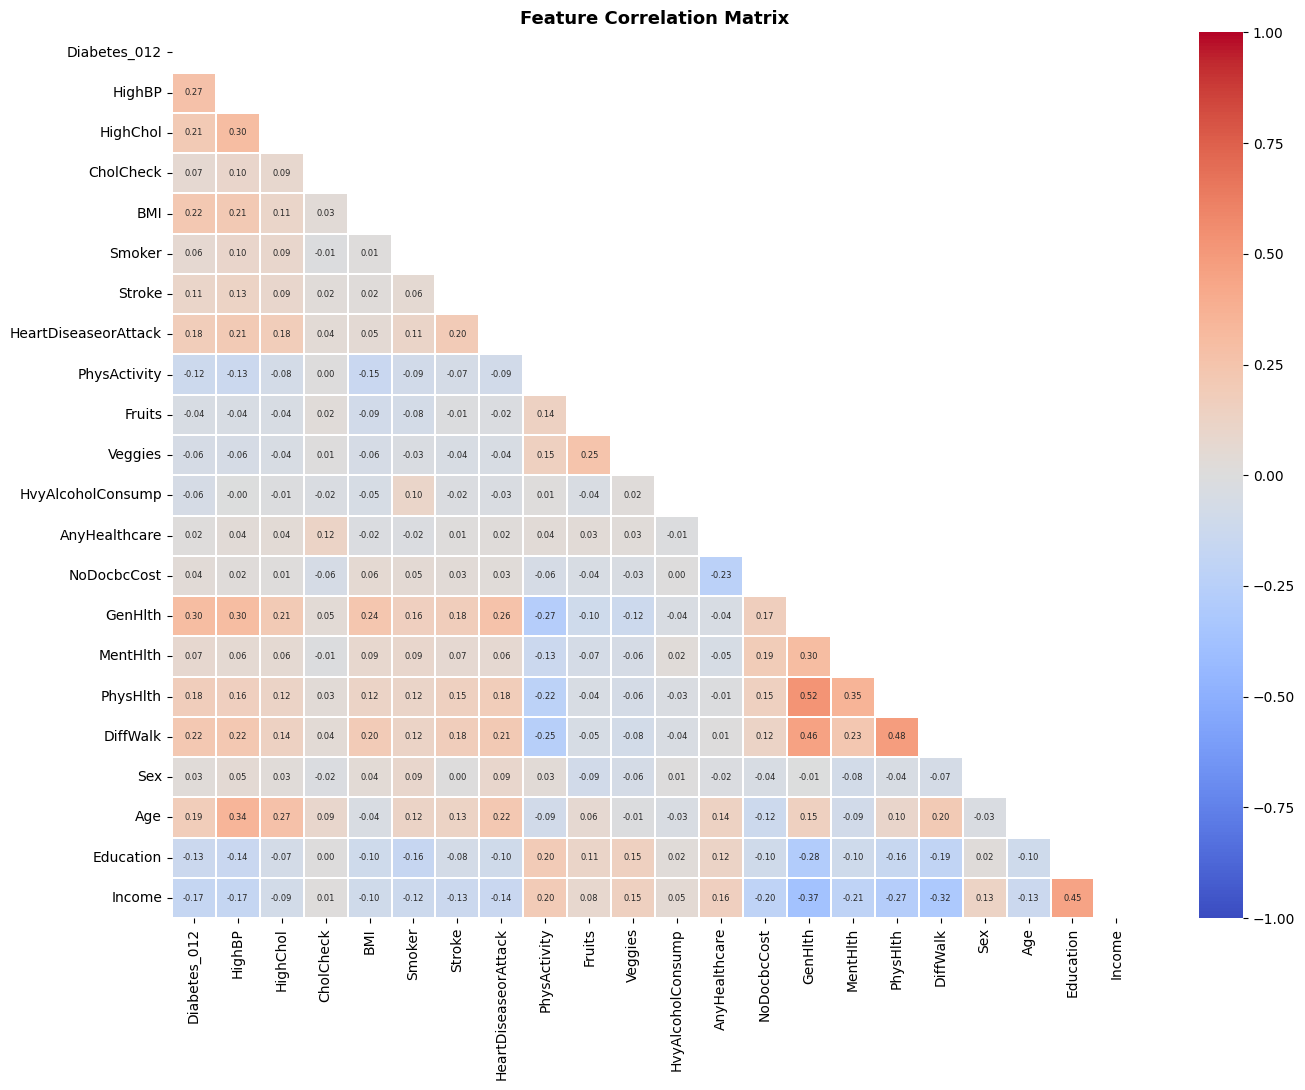

Saved: correlation_heatmap.png


In [ ]:

plt.figure(figsize=(14, 11))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix,
    mask      = mask,
    annot     = True,
    fmt       = '.2f',
    cmap      = 'coolwarm',
    center    = 0,
    linewidths= 0.3,
    annot_kws = {'size': 6},
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")


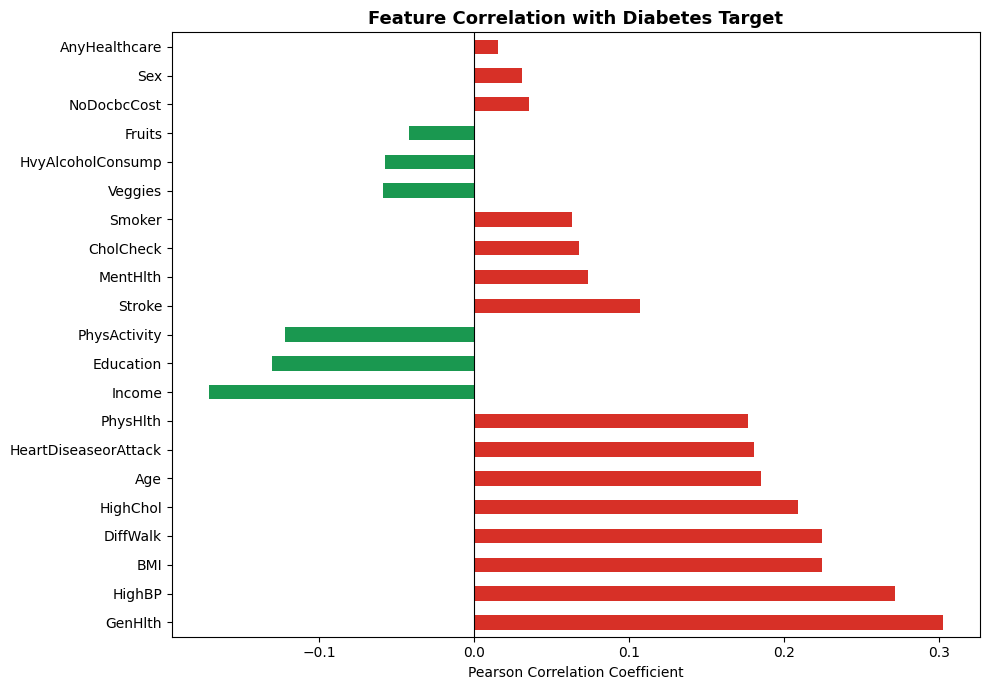

Top 5 features positively correlated with diabetes:
  GenHlth                        : +0.3026
  HighBP                         : +0.2716
  BMI                            : +0.2244
  DiffWalk                       : +0.2242
  HighChol                       : +0.2091

Top 5 features negatively correlated with diabetes:
  HvyAlcoholConsump              : -0.0579
  Fruits                         : -0.0422
  NoDocbcCost                    : 0.0354
  Sex                            : 0.0310
  AnyHealthcare                  : 0.0154


In [ ]:
# ───────────────── Top correlations with target ────────────────────────
target_corr = (
    df.corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 7))
colors_bar = ['#d73027' if x > 0 else '#1a9850' for x in target_corr]
target_corr.plot(kind='barh', color=colors_bar)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Diabetes Target', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('target_correlation.png', dpi=150)
plt.show()

print("Top 5 features positively correlated with diabetes:")
for feat, val in target_corr.head(5).items():
    print(f"  {feat:<30} : +{val:.4f}")
print("\nTop 5 features negatively correlated with diabetes:")
for feat, val in target_corr.tail(5).items():
    print(f"  {feat:<30} : {val:.4f}")


###4.4 BMI Analysis

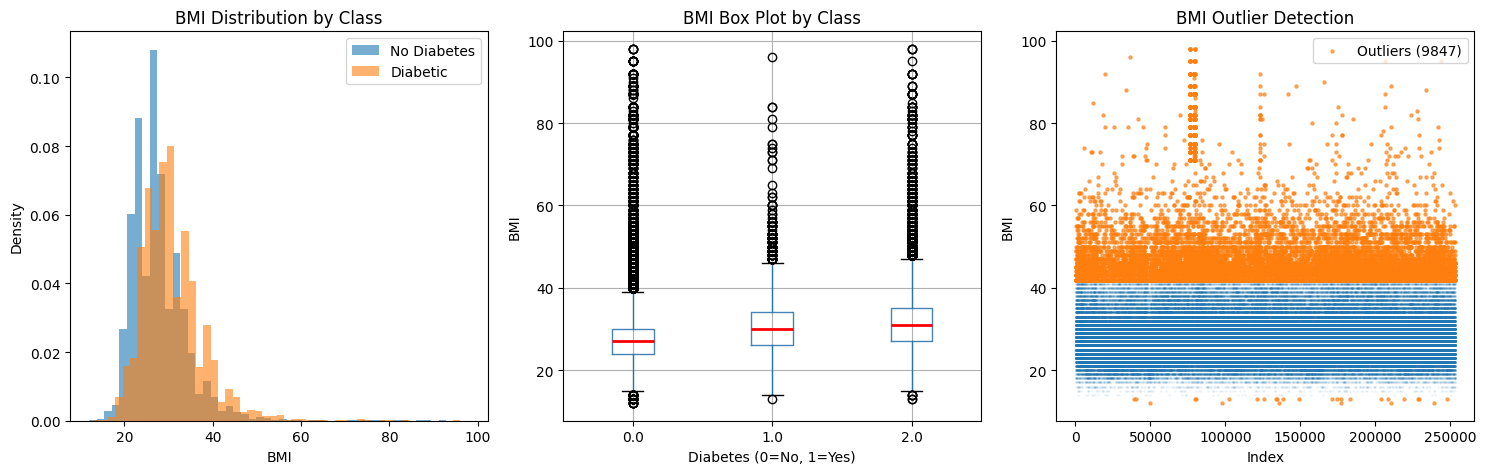

── BMI Statistics ─────────────────────────
Mean : 28.38
Std  : 6.61
Range: 12.0 — 98.0
Outliers (1.5×IQR): 9847 rows


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─────────────────────────────────────────
# 1. DISTRIBUTION
# ─────────────────────────────────────────
axes[0].hist(df[df[TARGET]==0]['BMI'], bins=50,
             alpha=0.6, label='No Diabetes', density=True)

axes[0].hist(df[df[TARGET]==1]['BMI'], bins=50,
             alpha=0.6, label='Diabetic', density=True)

axes[0].set_title('BMI Distribution by Class')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Density')
axes[0].legend()


# ─────────────────────────────────────────
# 2. BOXPLOT
# ─────────────────────────────────────────
df.boxplot(column='BMI', by=TARGET, ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))

axes[1].set_title('BMI Box Plot by Class')
axes[1].set_xlabel('Diabetes (0=No, 1=Yes)')
axes[1].set_ylabel('BMI')

# Remove automatic title
plt.suptitle("")


# ─────────────────────────────────────────
# 3. OUTLIER DETECTION
# ─────────────────────────────────────────
q1, q3 = df['BMI'].quantile([0.25, 0.75])
iqr = q3 - q1

# Standard rule
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

bmi_outliers = df[(df['BMI'] < lower) | (df['BMI'] > upper)]

axes[2].scatter(df.index, df['BMI'],
                alpha=0.05, s=1)

axes[2].scatter(bmi_outliers.index, bmi_outliers['BMI'],
                alpha=0.6, s=5, label=f'Outliers ({len(bmi_outliers)})')

axes[2].set_title('BMI Outlier Detection')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('BMI')
axes[2].legend()


# ─────────────────────────────────────────
# FINAL DISPLAY
# ─────────────────────────────────────────
plt.tight_layout()
plt.savefig('bmi_analysis.png', dpi=150)
plt.show()


# ─────────────────────────────────────────
# STATS
# ─────────────────────────────────────────
print("── BMI Statistics ─────────────────────────")
print(f"Mean : {df['BMI'].mean():.2f}")
print(f"Std  : {df['BMI'].std():.2f}")
print(f"Range: {df['BMI'].min()} — {df['BMI'].max()}")
print(f"Outliers (1.5×IQR): {len(bmi_outliers)} rows")

##5. Preprocessing
---
To prepare the diabetes health dataset for model training, several preprocessing techniques were applied, including:
- Data Cleaning
- Class Imbalance Handling (SMOTE)
- Feature Selection
- Train-Test Splitting

Processed data is used for training XGBoost and Random Forest



###5.1 Missing Value Handling


In [ ]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found.")
else:
    print(f"[WARNING] Missing values found:\n{missing[missing > 0]}")
    df = df.dropna()
    print(f"After dropping NaN rows: {df.shape}")

No missing values found.


###5.2 Duplicate rows

In [ ]:
dup = df.duplicated().sum()
print(f"\nDuplicated rows: {dup}")
if dup > 0:
    df = df.drop_duplicates()
    print(f"After removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")



Duplicated rows: 23899
After removing duplicates: (229781, 22)


###5.3 BMI outliers

In [ ]:
# BMI outlier handling (±3 std)
#-------------------------------

bmi_mean = df['BMI'].mean()
bmi_std  = df['BMI'].std()

bmi_low  = bmi_mean - 3 * bmi_std
bmi_high = bmi_mean + 3 * bmi_std

before_min = df['BMI'].min()
before_max = df['BMI'].max()

# Count outliers before clipping
outliers_before = ((df['BMI'] < bmi_low) | (df['BMI'] > bmi_high)).sum()

# Apply clipping
df['BMI'] = df['BMI'].clip(lower=bmi_low, upper=bmi_high)

after_min = df['BMI'].min()
after_max = df['BMI'].max()

# Count after clipping (should be 0)
outliers_after = ((df['BMI'] < bmi_low) | (df['BMI'] > bmi_high)).sum()

# ─────────────────────────────────────────
# OUTPUT
# ─────────────────────────────────────────
print("────────── BMI Outlier Handling ─────────────")
print(f"Mean BMI : {bmi_mean:.2f}")
print(f"Std Dev  : {bmi_std:.2f}")

print(f"\nClipping Range: [{bmi_low:.2f}, {bmi_high:.2f}]")

print(f"\nBefore Clipping:")
print(f"  Min = {before_min}, Max = {before_max}")
print(f"  Outliers = {outliers_before}")

print(f"\nAfter Clipping:")
print(f"  Min = {after_min:.2f}, Max = {after_max:.2f}")
print(f"  Outliers = {outliers_after}")

────────── BMI Outlier Handling ─────────────
Mean BMI : 28.69
Std Dev  : 6.79

Clipping Range: [8.33, 49.04]

Before Clipping:
  Min = 12.0, Max = 98.0
  Outliers = 2547

After Clipping:
  Min = 12.00, Max = 49.04
  Outliers = 0


###5.4 Validate binary feature values


In [ ]:


print("\n────────────── Validating Binary Feature Values ─────────────────")

invalid_count = 0
valid_set = {0, 1, 0.0, 1.0}

for feat in BINARY_FEATURES:
    unique_vals = set(df[feat].dropna().unique())

    if not unique_vals.issubset(valid_set):
        print(f"[WARNING] {feat} has invalid values → {sorted(unique_vals)}")
        invalid_count += 1
    else:
        print(f" - {feat} is valid")

# Summary
if invalid_count == 0:
    print("\n✔ All binary features are valid (0/1 only)")
else:
    print(f"\n⚠️ {invalid_count} features contain invalid values")

# ─────────────────────────────────────────
# FINAL DATASET READY
# ─────────────────────────────────────────

print(f"\nFinal clean shape: {df.shape}")

df_clean = df.copy()

print("df_clean is ready for splitting and SMOTE")


────────────── Validating Binary Feature Values ─────────────────
 - HighBP is valid
 - HighChol is valid
 - CholCheck is valid
 - Smoker is valid
 - Stroke is valid
 - HeartDiseaseorAttack is valid
 - PhysActivity is valid
 - Fruits is valid
 - Veggies is valid
 - HvyAlcoholConsump is valid
 - AnyHealthcare is valid
 - NoDocbcCost is valid
 - DiffWalk is valid
 - Sex is valid

✔ All binary features are valid (0/1 only)

Final clean shape: (229781, 22)
df_clean is ready for splitting and SMOTE


###5.5 Train / Val / Test Split
---

In [ ]:
X = df_clean[ALL_FEATURES]
# Convert 'Diabetes_012' to binary: 0 (No Diabetes) and 1 (Prediabetes or Diabetes)
y = df_clean[TARGET].replace({2.0: 1.0})

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Class counts   : {dict(y.value_counts())}")

# Split the dataset into training, validation, and test sets

# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: 75% train, 25% val (of trainval)
# This gives overall: 60% train, 20% val, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Features shape : (229781, 21)
Target shape   : (229781,)
Class counts   : {0.0: np.int64(190055), 1.0: np.int64(39726)}
Train: (137868, 21)
Val  : (45956, 21)
Test : (45957, 21)


###5.6 SMOTE
SMOTE is used to handle class imbalance by generating synthetic minority class samples

───────────── Before SMOTE ──────────────
Train shape  : (137868, 21)
Class counts : {0.0: np.int64(114032), 1.0: np.int64(23836)}
Imbalance ratio: 4.78 : 1

──────────────────────── After SMOTE ─────────────────────────
Train shape  : (228064, 21)
Class counts : {0.0: np.int64(114032), 1.0: np.int64(114032)}
Added samples: 90,196


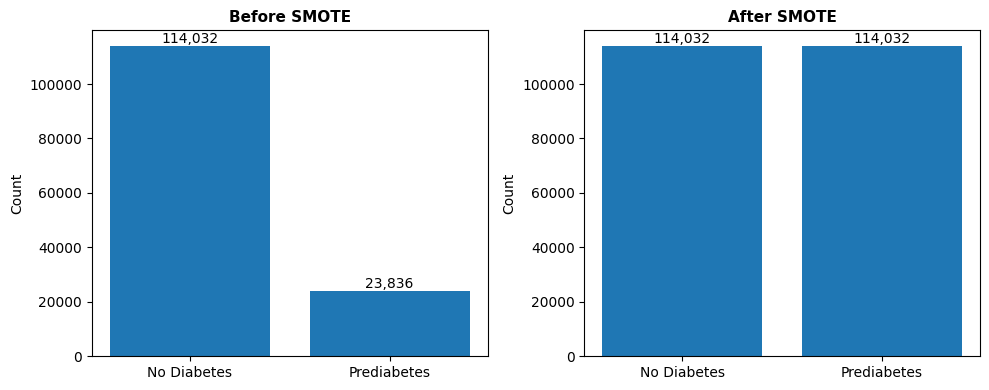

Saved: smote_before_after.png


In [ ]:
# SMOTE — HANDLE CLASS IMBALANCE
#--------------------------------------

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd

# Before SMOTE
before_counts = pd.Series(y_train).value_counts().sort_index() # Sort to ensure consistent order

print("───────────── Before SMOTE ──────────────")
print(f"Train shape  : {X_train.shape}")
print(f"Class counts : {dict(before_counts)}")

imb_ratio = before_counts.max() / before_counts.min()
print(f"Imbalance ratio: {imb_ratio:.2f} : 1")

# Apply SMOTE (only on training set)
smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=5,
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# After SMOTE
after_counts = pd.Series(y_train_sm).value_counts().sort_index() # Sort to ensure consistent order

print("\n──────────────────────── After SMOTE ─────────────────────────")
print(f"Train shape  : {X_train_sm.shape}")
print(f"Class counts : {dict(after_counts)}")
print(f"Added samples: {len(X_train_sm) - len(X_train):,}")

# ─────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Define labels for the three classes based on common understanding in the context of diabetes
class_labels = {
    0.0: 'No Diabetes',
    1.0: 'Prediabetes',
    2.0: 'Diabetes'
}

for ax, counts, title in [
    (axes[0], before_counts, "Before SMOTE"),
    (axes[1], after_counts,  "After SMOTE")
]:
    # Ensure labels match the sorted index of counts
    labels = [class_labels.get(idx, f'Class {idx}') for idx in counts.index]
    ax.bar(labels, counts.values)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')

    # Dynamic text placement
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.01, f'{v:,}', ha='center')

plt.tight_layout()
plt.savefig('smote_before_after.png', dpi=150)
plt.show()

print("Saved: smote_before_after.png")

##6. Model Building
---
Random Forest and XGBoost models are used for health risk prediction, and their performance is compared to select the best model.

**XGBoost** model is:

- Gradient boosting algorithm
- High performance and accuracy
- Handles complex patterns
- Efficient and optimized

The models are trained on health indicators such as BMI, age, and lifestyle factors to classify individuals into high-risk or low-risk categories.

In [ ]:
# XGBoost Classifier
#--------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    gamma             = 1,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       ='logloss',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)

In [ ]:
# Random Forest as comparison
#-------------------------------
rf_model = RandomForestClassifier(
    n_estimators      = 300,
    max_depth         = 10,
    min_samples_split = 10,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)

##7. Model Training
---
Model learns patterns : risk vs no risk

In [ ]:

# XGBoost
#------------
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=30,
    verbose=50
)

print("\nXGBoost training complete.")

[0]	validation_0-logloss:0.67462
[50]	validation_0-logloss:0.42779
[100]	validation_0-logloss:0.38872
[150]	validation_0-logloss:0.37770
[200]	validation_0-logloss:0.37347
[250]	validation_0-logloss:0.37140
[300]	validation_0-logloss:0.37034
[350]	validation_0-logloss:0.36987
[400]	validation_0-logloss:0.36975
[450]	validation_0-logloss:0.36966
[499]	validation_0-logloss:0.36964

XGBoost training complete.


In [ ]:
# Random Forest
#------------------
rf_model.fit(X_train_sm, y_train_sm)

print("Random Forest training complete.")

Random Forest training complete.


##8. Model Evaluation
---

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, X_test, y_test, name):

    # Predictions
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)


    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")

    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['No Diabetes', 'Diabetic']))

    return y_pred, y_proba, auc

xgb_pred, xgb_proba, xgb_auc = evaluate_model(xgb_model, X_test, y_test, "XGBoost")
rf_pred,  rf_proba,  rf_auc  = evaluate_model(rf_model,  X_test, y_test, "Random Forest")


  XGBoost
  Accuracy : 0.8377
  F1 Score : 0.3177
  AUC-ROC  : 0.8132
              precision    recall  f1-score   support

 No Diabetes       0.86      0.97      0.91     38012
    Diabetic       0.58      0.22      0.32      7945

    accuracy                           0.84     45957
   macro avg       0.72      0.59      0.61     45957
weighted avg       0.81      0.84      0.81     45957


  Random Forest
  Accuracy : 0.7992
  F1 Score : 0.4648
  AUC-ROC  : 0.8007
              precision    recall  f1-score   support

 No Diabetes       0.89      0.86      0.88     38012
    Diabetic       0.43      0.50      0.46      7945

    accuracy                           0.80     45957
   macro avg       0.66      0.68      0.67     45957
weighted avg       0.81      0.80      0.81     45957



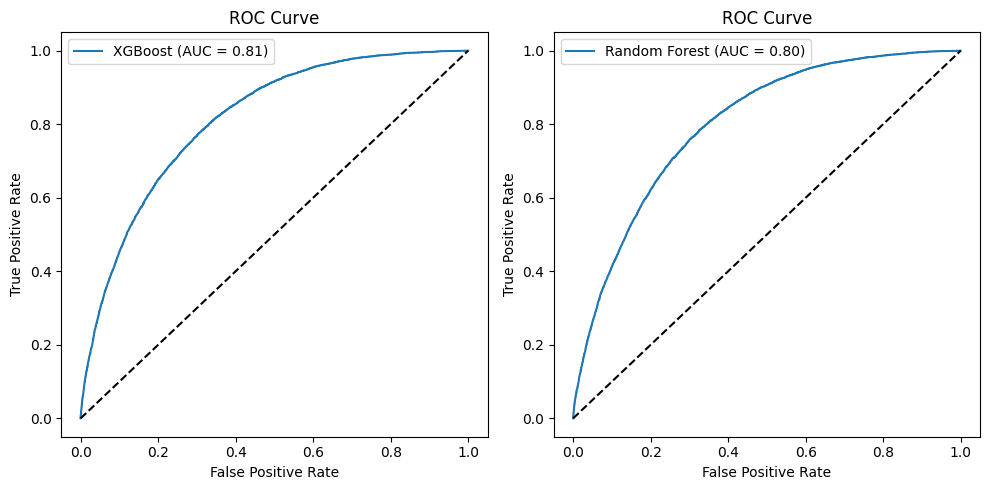

In [ ]:
# ROC Curve
#----------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for model, ax, name, auc_score in [
    (xgb_model, axes[0], "XGBoost", xgb_auc),
    (rf_model,  axes[1], "Random Forest", rf_auc)
]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

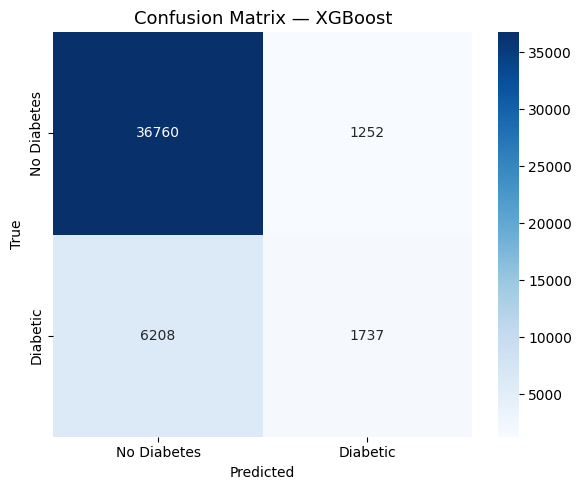

In [ ]:
# Confusion Matrix
#-------------------
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetic'],
            yticklabels=['No Diabetes','Diabetic'])
plt.title('Confusion Matrix — XGBoost', fontsize=13)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()

##9. SHAP Explainability
---
SHAP (SHapley Additive exPlanations) is used to explain how each feature contributes to the model’s prediction.

- SHAP (SHapley Additive exPlanations) is a model interpretability technique based on game theory.

- It helps in understanding:
  - Why a prediction was made
  - Which features are important
  - How each feature affects the output

- Here SHAP will identify features that impact  on health risk, thereby improving the explainability and readability of the model

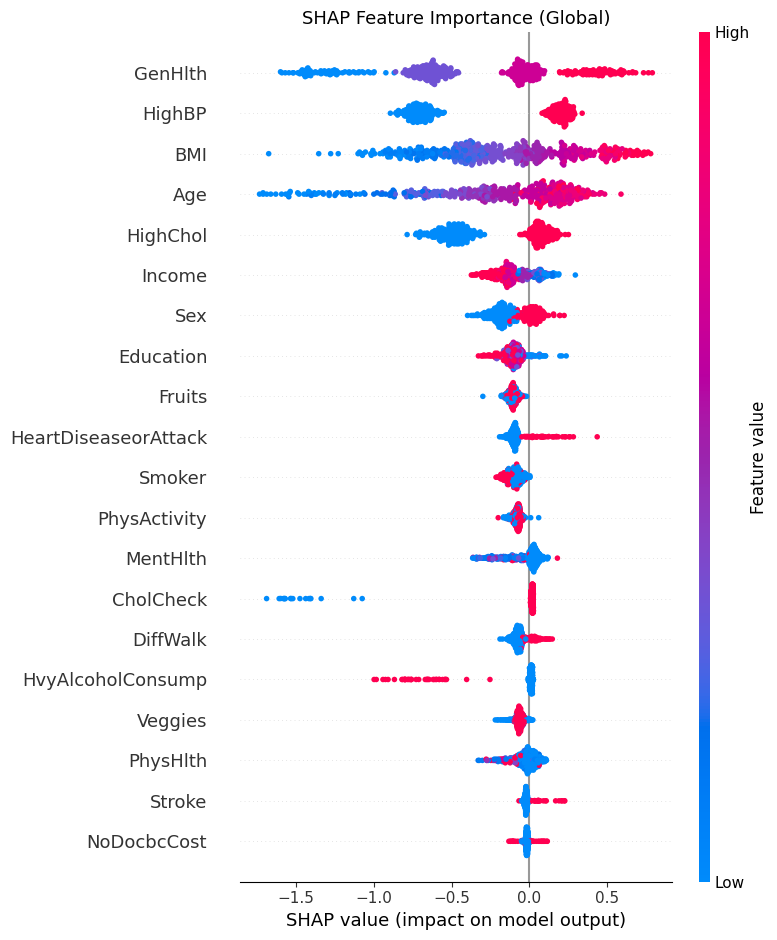

In [ ]:
import shap
import matplotlib.pyplot as plt

# SHAP Explainer for XGBoost
#-----------------------------------
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
# For binary classification with XGBoost, shap_values is often a 2D array (n_samples, n_features)
shap_values = explainer.shap_values(X_test[:500])

# Summary Plot (global feature importance)
plt.figure(figsize=(10, 6))
# Fix: Pass the entire shap_values matrix, not a single row (vector)
shap.summary_plot(shap_values, X_test[:500], show=False, feature_names=ALL_FEATURES)

plt.title('SHAP Feature Importance (Global)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

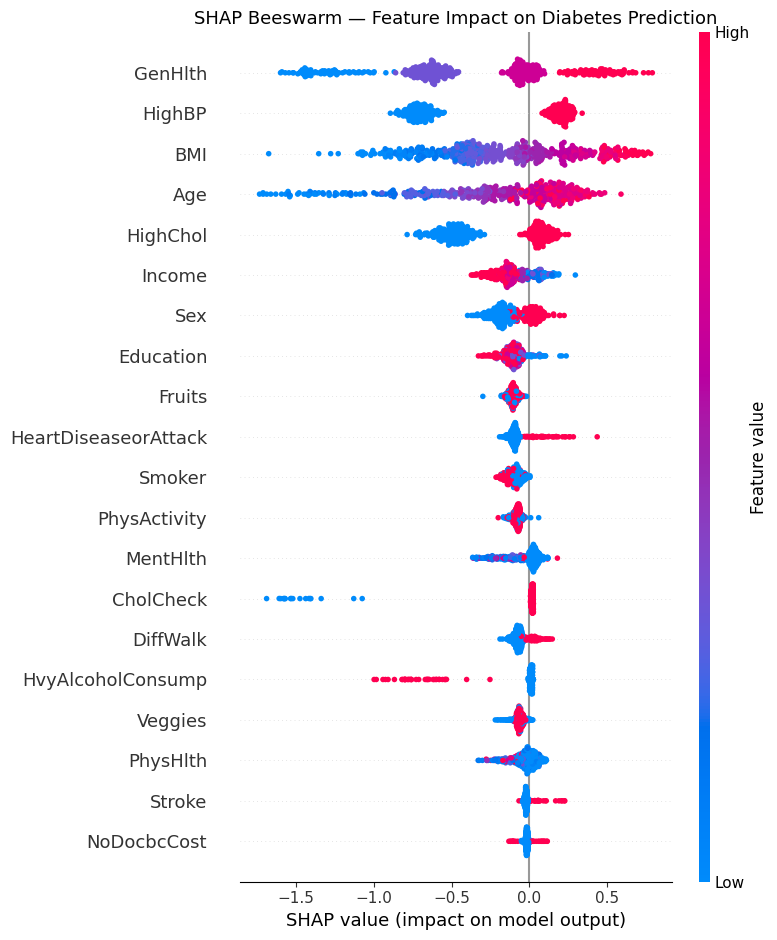

In [ ]:
# SHAP beeswarm plot (distribution of impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:500], feature_names=ALL_FEATURES, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Diabetes Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150)
plt.show()

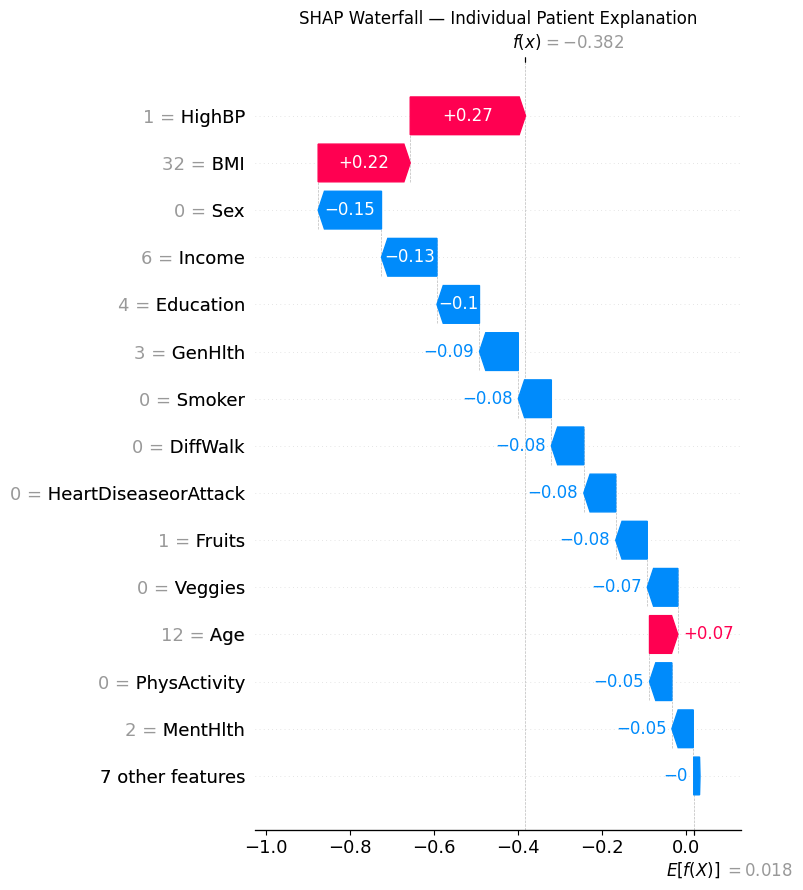

In [ ]:
# Waterfall plot for a single patient prediction
shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=ALL_FEATURES
)
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Individual Patient Explanation', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150)
plt.show()

##10. Save Model
---

In [ ]:
pickle.dump(xgb_model, open('health_risk_xgb.pkl', 'wb'))
pickle.dump(rf_model,  open('health_risk_rf.pkl',  'wb'))
pickle.dump(ALL_FEATURES,  open('health_features.pkl', 'wb'))

!cp health_risk_xgb.pkl  /content/drive/MyDrive/
!cp health_risk_rf.pkl   /content/drive/MyDrive/
!cp health_features.pkl  /content/drive/MyDrive/
print("Models saved to Drive.")

Models saved to Drive.


##11.Inference Function
---
## Diabetes Risk Prediction with SHAP Explanation

This function predicts the diabetes risk for a single patient using a trained XGBoost model.

It also uses SHAP (SHapley Additive Explanations) to identify the most important features contributing to the prediction. This helps in understanding why the model made a particular decision.

The output includes:
- Risk Level (Low / Moderate / High)
- Probability of diabetes
- Top contributing factors (using SHAP values)

In [ ]:
def predict_diabetes_risk(input_data: dict,
                           model_path='health_risk_xgb.pkl',
                           features_path='health_features.pkl') -> dict:
    """
    Predict diabetes risk for a single patient.

    Args:
        input_data : dict  — keys = feature names, values = patient values
        model_path : str   — path to saved XGBoost model
        features_path: str — path to saved feature list

    Returns:
        dict with 'risk_level', 'probability', and 'top_factors'
    """
    model    = pickle.load(open(model_path, 'rb'))
    features = pickle.load(open(features_path, 'rb'))

    row = pd.DataFrame([input_data])[features]
    prob = model.predict_proba(row)[0][1]

    if prob < 0.3:
        risk = "Low"
    elif prob < 0.6:
        risk = "Moderate"
    else:
        risk = "High"

    # SHAP for this patient
    explainer   = shap.TreeExplainer(model)
    sv           = explainer.shap_values(row)[0]
    top_idx      = np.argsort(np.abs(sv))[::-1][:5]
    top_factors  = [(features[i], round(float(sv[i]), 4)) for i in top_idx]

    result = {
        'risk_level'  : risk,
        'probability' : round(float(prob) * 100, 2),
        'top_factors' : top_factors
    }
    print('='*90)
    print(f"                             Diabetes Risk Assessment")
    print('='*90)
    print(f"   - Patient Data : {input_data}")
    print(f"   - Risk Level   : {risk}")
    print(f"   - Probability  : {result['probability']}%")
    print(f"\n   - Top Factors  :")
    for feat, val in top_factors:
        direction = "↑ increases" if val > 0 else "↓ decreases"
        print(f"     • {feat:<28} {direction} risk  (SHAP={val:+.4f})")
    print("\n⚠ THIS IS NOT A MEDICAL DIAGNOSIS, CONSULT YOUR DOCTOR.")
    return



In [ ]:
# Example usage
sample_patient = {
    'HighBP': 1,
    'HighChol': 1,
    'CholCheck': 1,
    'BMI': 32,
    'Smoker': 0,
    'Stroke': 0,
    'HeartDiseaseorAttack': 0,
    'PhysActivity': 0,
    'Fruits': 1,
    'Veggies': 1,
    'HvyAlcoholConsump': 0,
    'AnyHealthcare': 1,
    'NoDocbcCost': 0,
    'GenHlth': 3,
    'MentHlth': 5,
    'PhysHlth': 10,
    'DiffWalk': 0,
    'Sex': 1,
    'Age': 9,
    'Education': 4,
    'Income': 5
}
predict_diabetes_risk(sample_patient)

                             Diabetes Risk Assessment
   - Patient Data : {'HighBP': 1, 'HighChol': 1, 'CholCheck': 1, 'BMI': 32, 'Smoker': 0, 'Stroke': 0, 'HeartDiseaseorAttack': 0, 'PhysActivity': 0, 'Fruits': 1, 'Veggies': 1, 'HvyAlcoholConsump': 0, 'AnyHealthcare': 1, 'NoDocbcCost': 0, 'GenHlth': 3, 'MentHlth': 5, 'PhysHlth': 10, 'DiffWalk': 0, 'Sex': 1, 'Age': 9, 'Education': 4, 'Income': 5}
   - Risk Level   : Moderate
   - Probability  : 41.83%

   - Top Factors  :
     • HighBP                       ↑ increases risk  (SHAP=+0.2671)
     • BMI                          ↑ increases risk  (SHAP=+0.1738)
     • DiffWalk                     ↓ decreases risk  (SHAP=-0.1219)
     • Smoker                       ↓ decreases risk  (SHAP=-0.1093)
     • Fruits                       ↓ decreases risk  (SHAP=-0.1041)

⚠ THIS IS NOT A MEDICAL DIAGNOSIS, CONSULT YOUR DOCTOR.
